In [1]:
!pip install --quiet "numpy<2" opencv-python torch torchvision captum

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
sys.path.insert(1, '../')
import helpers, os
from PIL import Image
import cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from helpers.attribution import convert_to_uint8

device = helpers.models.get_device()

In [2]:
from helpers.attribution import get_attr_pth

## Debug Split Image Attr.

In [ ]:
data_df = pd.read_csv("/home/local/data/sophie/processed_meta_full.csv")
test_df = data_df.query("Partition == 'Test' and label ==1").reset_index(drop=True)

# bboxes @ resolution 224
bbox_df = helpers.bboxes.read_bounding_boxes("/home/local/data/sophie/node21_combined/all_bboxes.csv")

results_df = pd.DataFrame() 
results_df['image'] = test_df["mha"].apply(lambda x :x[:-4])

In [11]:
mapping_df = pd.read_csv("../split_node21_sets/crop/test/process_log.csv",\
                         header=None, names= ["mha","process","std","resolution","distribution","half","x","y","w","h"])

In [12]:
mapping_df

,mha,process,std,resolution,distribution,half,x,y,w,h
c3820.mha,crop,NaN,std,1024,test,NaN,0,0,0,0
c1856.mha,crop,NaN,std,1024,test,NaN,0,0,0,0
n0014.mha,crop,NaN,std,1024,test,left,476,1348,141,145
c2658.mha,crop,NaN,std,1024,test,NaN,0,0,0,0
n0581.mha,crop,NaN,std,1024,test,right,129,595,44,52
...,...,...,...,...,...,...,...,...,...,...
n0060.mha,crop,NaN,std,1024,test,left,410,182,42,53
n0902.mha,crop,NaN,std,1024,test,left,285,522,90,78
c2727.mha,crop,NaN,std,1024,test,NaN,0,0,0,0
c2241.mha,crop,NaN,std,1024,test,NaN,0,0,0,0


In [13]:
mapping_df.w.max()

400

In [16]:
mapping_df.h.max()

396

In [17]:
mapping_df.x.max()

2414

In [18]:
mapping_df.y.max()

2139

## Load Occ Attrs

### Full Models

In [3]:
data_df = pd.read_csv("/home/local/data/sophie/processed_meta_full.csv")
test_df = data_df.query("Partition == 'Test' and label ==1").reset_index(drop=True)

# bboxes @ resolution 224
bbox_df = helpers.bboxes.read_bounding_boxes("/home/local/data/sophie/node21_combined/all_bboxes.csv")

In [ ]:
results_df = pd.DataFrame() 
results_df['image'] = test_df["mha"].apply(lambda x :x[:-4])

In [90]:
attr_type = "occ" #"int"
training_type = "full"
for weight_type in ["base", "grey", "single", "base65", "grey65", "single65"]:
    # run_seed = 42 # 43 44
    results_df = pd.DataFrame() 
    results_df['image'] = test_df["mha"].apply(lambda x :x[:-4])
    for run_seed in [42, 43, 44]:
        ious = []
        coverages = []
        noises = []
        intersects = []
        
        for img in results_df.image:
            try:
                curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[img]], 224, 512)
                curr_bbox_reshaped = [curr_bbox[0][0], curr_bbox[0][1], curr_bbox[0][0]+curr_bbox[0][2], curr_bbox[0][1]+curr_bbox[0][3]]
                curr_pth = get_attr_pth(attr_type, training_type, weight_type, run_seed, img)
                curr_attr = helpers.attribution.load_attr(curr_pth)
                curr_attr =  cv2.threshold(curr_attr, 170, 255, cv2.THRESH_BINARY)[1]
                best_iou = 0.0
                curr_noise = 0
                best_cov = None
                curr_intersect = 0
                # curr_attr_bboxes = helpers.attribution.df_cc_bboxes_by_dbscan(helpers.attribution.attribution_bbox_with_connected_components(curr_attr))
                # for box in curr_attr_bboxes:
                curr_attr_bboxes =helpers.attribution.attribution_bbox_with_connected_components(curr_attr)
                for i in range(0,len(curr_attr_bboxes)):
                    box = [curr_attr_bboxes.iloc[i].xmin, curr_attr_bboxes.iloc[i].ymin, curr_attr_bboxes.iloc[i].xmax, curr_attr_bboxes.iloc[i].ymax] 
                    curr_iou = helpers.intersection.calculate_iou(curr_bbox_reshaped, np.asarray(box))
                    
                    if not curr_iou > 0.0:
                        curr_noise += 1
                    if curr_iou > best_iou:
                        best_iou = curr_iou
                        best_cov = helpers.intersection.calculate_intersect_coverage(curr_bbox_reshaped, np.asarray(box))
                        curr_intersect = 1
                        
                ious.append(best_iou)
                coverages.append(best_cov)
                noises.append(curr_noise)
                intersects.append(curr_intersect)
            except:
                ious.append(pd.NA)
                coverages.append(pd.NA)
                noises.append(pd.NA)
                intersects.append(pd.NA)
                pass
        
        results_df[f'iou_{run_seed}'] = ious
        results_df[f'noise_{run_seed}'] = noises
        results_df[f'coverage_{run_seed}'] = coverages
        results_df[f'intersect_{run_seed}'] = intersects
    results_df.to_csv(f"occ_metrics/image_metrics/{attr_type}_{weight_type}_{training_type}_iou_score_cc-only.csv")

[ WARN:0@3589.117] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0098.png'): can't open/read file: check file path/integrity
[ WARN:0@3589.117] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0777.png'): can't open/read file: check file path/integrity
[ WARN:0@3589.117] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0240.png'): can't open/read file: check file path/integrity
[ WARN:0@3589.117] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n1048.png'): can't open/read file: check file path/integrity
[ WARN:0@3589.118] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0305.png'): can't open/read file: check 

### First Models

In [4]:
data_df = pd.read_csv("/home/local/data/sophie/processed_meta_full.csv")
test_df = data_df.query("Partition == 'Test' and label ==1").reset_index(drop=True)

# bboxes @ resolution 224
bbox_df = helpers.bboxes.read_bounding_boxes("/home/local/data/sophie/node21_combined/all_bboxes.csv")

In [91]:
attr_type = "occ" #"int"
training_type = "first"
for weight_type in ["base", "base65", "grey65", "single65"]:
    # run_seed = 42 # 43 44
    results_df = pd.DataFrame() 
    results_df['image'] = test_df["mha"].apply(lambda x :x[:-4])
    for run_seed in [42, 43, 44]:
        ious = []
        coverages = []
        noises = []
        intersects = []
        
        for img in results_df.image:
            try:
                curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[img]], 224, 512)
                curr_bbox_reshaped = [curr_bbox[0][0], curr_bbox[0][1], curr_bbox[0][0]+curr_bbox[0][2], curr_bbox[0][1]+curr_bbox[0][3]]
                curr_pth = get_attr_pth(attr_type, training_type, weight_type, run_seed, img)
                curr_attr = helpers.attribution.load_attr(curr_pth)
                curr_attr =  cv2.threshold(curr_attr, 170, 255, cv2.THRESH_BINARY)[1]
                best_iou = 0.0
                curr_noise = 0
                best_cov = None
                curr_intersect = 0
                # curr_attr_bboxes = helpers.attribution.df_cc_bboxes_by_dbscan(helpers.attribution.attribution_bbox_with_connected_components(curr_attr))
                # for box in curr_attr_bboxes:
                curr_attr_bboxes =helpers.attribution.attribution_bbox_with_connected_components(curr_attr)
                for i in range(0,len(curr_attr_bboxes)):
                    box = [curr_attr_bboxes.iloc[i].xmin, curr_attr_bboxes.iloc[i].ymin, curr_attr_bboxes.iloc[i].xmax, curr_attr_bboxes.iloc[i].ymax] 
                    curr_iou = helpers.intersection.calculate_iou(curr_bbox_reshaped, np.asarray(box))
                    
                    if not curr_iou > 0.0:
                        curr_noise += 1
                    if curr_iou > best_iou:
                        best_iou = curr_iou
                        best_cov = helpers.intersection.calculate_intersect_coverage(curr_bbox_reshaped, np.asarray(box))
                        curr_intersect = 1
                        
                ious.append(best_iou)
                coverages.append(best_cov)
                noises.append(curr_noise)
                intersects.append(curr_intersect)
            except:
                ious.append(pd.NA)
                coverages.append(pd.NA)
                noises.append(pd.NA)
                intersects.append(pd.NA)
                pass
        
        results_df[f'iou_{run_seed}'] = ious
        results_df[f'noise_{run_seed}'] = noises
        results_df[f'coverage_{run_seed}'] = coverages
        results_df[f'intersect_{run_seed}'] = intersects
    results_df.to_csv(f"occ_metrics/image_metrics/{attr_type}_{weight_type}_{training_type}_iou_score_cc-only.csv")

[ WARN:0@3860.530] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/first/base/model1/n0098.png'): can't open/read file: check file path/integrity
[ WARN:0@3860.530] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/first/base/model1/n0777.png'): can't open/read file: check file path/integrity
[ WARN:0@3860.530] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/first/base/model1/n0240.png'): can't open/read file: check file path/integrity
[ WARN:0@3860.530] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/first/base/model1/n1048.png'): can't open/read file: check file path/integrity
[ WARN:0@3860.530] global loadsave.cpp:268 findDecoder imread_('/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/first/base/model1/n0305.png'): can't open/read file: c

## Average Occ Metrics

In [107]:
import os
import pandas as pd
import re

csv_dir = 'occ_metrics/image_metrics'

summary_rows = []
per_seed_rows = []

for filename in os.listdir(csv_dir):
    if filename.endswith('_iou_score_cc-only.csv'):
        try:
            attr_type, weight_type, training_type, _ = filename.split('_', 3)
        except ValueError:
            print(f"Skipping file with unexpected name: {filename}")
            continue

        df = pd.read_csv(os.path.join(csv_dir, filename))

        metrics_by_seed = {}
        for col in df.columns:
            match = re.match(r'(\w+)_(\d+)', col)
            if match:
                metric, seed = match.groups()
                metrics_by_seed.setdefault(seed, {}).setdefault(metric, []).append(df[col])

        iou_means, noise_means, coverage_means, intersect_means = [], [], [], []

        for seed, metrics in metrics_by_seed.items():
            # Compute mean of all image values per seed+metric
            iou_avg = pd.concat(metrics.get('iou', []), axis=1).mean(axis=1).mean()
            noise_avg = pd.concat(metrics.get('noise', []), axis=1).mean(axis=1).mean()
            coverage_avg = pd.concat(metrics.get('coverage', []), axis=1).mean(axis=1).mean()
            intersect_avg = pd.concat(metrics.get('intersect', []), axis=1).mean(axis=1).mean()

            # Save for summary
            iou_means.append(iou_avg)
            noise_means.append(noise_avg)
            coverage_means.append(coverage_avg)
            intersect_means.append(intersect_avg)

            # Save per-seed row
            per_seed_rows.append({
                'attr_type': attr_type,
                'weight_type': weight_type,
                'training_type': training_type,
                'seed': seed,
                'iou': iou_avg,
                'noise': noise_avg,
                'coverage': coverage_avg,
                'intersect': intersect_avg
            })

        summary_rows.append({
            'attr_type': attr_type,
            'weight_type': weight_type,
            'training_type': training_type,
            'iou_mean': pd.Series(iou_means).mean(),
            'iou_std': pd.Series(iou_means).std(),
            'noise_mean': pd.Series(noise_means).mean(),
            'noise_std': pd.Series(noise_means).std(),
            'coverage_mean': pd.Series(coverage_means).mean(),
            'coverage_std': pd.Series(coverage_means).std(),
            'intersect_mean': pd.Series(intersect_means).mean(),
            'intersect_std': pd.Series(intersect_means).std()
        })

# Create final DataFrames
summary_df = pd.DataFrame(summary_rows)
per_seed_df = pd.DataFrame(per_seed_rows)

# Optional sorting
summary_df = summary_df.sort_values(by=['weight_type', 'training_type'])
per_seed_df = per_seed_df.sort_values(by=['weight_type', 'training_type', 'seed'])

summary_df.to_csv("occ_metrics/summary_scores.csv", index=False)
per_seed_df.to_csv("occ_metrics/summary_scores_with_seeds.csv", index=False)

## Generate IG Attrs

In [4]:
def get_best_epoch(seed, strategy, config):
    # Define mapping of (seed, strategy, config) to best epoch number
    best_epoch_map = {
        # Format: (seed, strategy, config): best_epoch_number
        (42, "full", "base"): 35,
        (43, "full", "base"): 38,
        (44, "full", "base"): 29,
        (42, "full", "grey"): 17,
        (43, "full", "grey"): 38,
        (44, "full", "grey"): 23,
        (42, "full", "single"): 18,
        (43, "full", "single"): 38,
        (44, "full", "single"): 34,
        (42, "first", "base"): 31,
        (43, "first", "base"): 38,
        (44, "first", "base"): 37,
        (42, "first", "grey"): 19,
        (43, "first", "grey"): 35,
        (44, "first", "grey"): 37,
        (42, "first", "single"): 39,
        (43, "first", "single"): 19,
        (44, "first", "single"): 26,   
    }
    
    # Create the key tuple
    key = (seed, strategy.lower(), config.lower())
    
    # Return the best epoch number if the key exists
    if key in best_epoch_map:
        return best_epoch_map[key]
    else:
        raise ValueError(f"No best epoch found for seed={seed}, strategy={strategy}, config={config}")

In [ ]:
bbox_df = helpers.bboxes.read_bounding_boxes("/home/local/data/sophie/node21_combined/all_bboxes.csv")
root_pth = "/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/"
for train_strat in os.listdir(root_pth):
    if train_strat in ['first_layer_freeze']:
        for weight in os.listdir(os.path.join(root_pth,train_strat)):
            if weight in ["base","grey","single"]:
                for config in os.listdir(os.path.join(root_pth,train_strat, weight)):
                    if "step_decay_50_epochs" not in config:
                        results_df = pd.DataFrame() 
                        for model_name in os.listdir(os.path.join(root_pth,train_strat, weight, config)):
                            if model_name != "archive" and "tweak" not in model_name and int(model_name.split("_")[8])<=44: #skip tweak models and other seeds
                                
                                curr_seed = model_name.split("_")[8]
                                epoch = get_best_epoch(int(curr_seed), train_strat.split("_")[0],weight)
                                # model_name+="/model_17.pth"
                                model_name+=f"/model_{epoch}.pth" #load best epoch
                                model_pth = os.path.join(root_pth,train_strat, weight, config, model_name)
                                print(f"processing model {model_pth}")
                                # load model
                                curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
                                # load to GPU
                                curr_model=curr_model.to(device)
                                # create gradient model
                                curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
                                ious = []
                                coverages = []
                                noises = []
                                intersects = []
                                img_names = []
                                testset_names =[]
                                # iterate over test sets
                                for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
                                    # load data -> bsz = 1
                                    dataset = helpers.dataloading.load_dataset_with_paths(
                                        dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
                                        dataset_name=data_name,
                                        process="arch",
                                        crop_size=512,
                                        batch_size=1,
                                        shuffle=False,
                                        single_channel = True if "single" in weight else False
                                    )
                                    # iterate over data samples
                                    for data in dataset:
                                        # check for nodule
                                        if data[1] == 1:
                                            # load to device
                                            pos_input, pos_path = data[0].to(device),data[2][0]
                                            img_names.append(pos_path.split("/")[-1][:-4])
                                            testset_names.append(data_name)
                                            # generate attr
                                            int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
                                                curr_int_model, pos_input[0], 1, 
                                                single= True if "single" in weight else False, 
                                                window=8).squeeze(0)[0].cpu().numpy()
                                            # calculate attr bboxes
                                            attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
                                                helpers.attribution.get_area_thresheld_connected_components(
                                                    helpers.attribution.threshold_attributions(
                                                        int_attr, 
                                                        min_thresh_frac=0.25, 
                                                        binary_mask=True
                                                        )), 30)
                                            # get current true bbox
                                            pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
                                            # convert from [x,y,w,h] to [x1,y1,x2,y2]
                                            pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
                                            # track metrics
                                            best_iou = 0.0
                                            curr_noise = 0
                                            best_cov = None
                                            curr_intersect = 0
                                            for i in range(0,len(attr_boxes)):
                                                box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
                                                curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox, np.asarray(box))
                                                if not curr_iou > 0.0:
                                                    curr_noise += 1
                                                if curr_iou > best_iou:
                                                    best_iou = curr_iou
                                                    best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox, np.asarray(box))
                                                    curr_intersect = 1  
                                            ious.append(best_iou)
                                            coverages.append(best_cov)
                                            noises.append(curr_noise)
                                            intersects.append(curr_intersect)
                                            pos_input =  pos_input.to("cpu")
                                results_df['img'] = img_names
                                results_df['test_set'] = testset_names
                                results_df[f'iou_{curr_seed}'] = ious
                                results_df[f'noise_{curr_seed}'] = noises
                                results_df[f'coverage_{curr_seed}'] = coverages
                                results_df[f'intersect_{curr_seed}'] = intersects
                                print("Done!")
                        # move model back to CPU
                        curr_model = curr_model.to("cpu")
                        # results_df.to_csv(f"int_metrics/image_metrics/int_{weight}_{train_strat}_iou_score.csv")
                        results_df.to_csv(f"int_metrics/image_metrics/f1-optim/int_{weight}_{train_strat}_iou_score.csv")
    
                    else:
                        pass

## Average IG Metrics

In [6]:
results_df = pd.read_csv("int_metrics/image_metrics/int_base_first_layer_freeze_iou_score.csv")

In [13]:
import os
import pandas as pd
import re

# csv_dir = 'int_metrics/image_metrics'
csv_dir = 'int_metrics/image_metrics/f1-optim'

summary_rows = []
per_seed_rows = []

for filename in os.listdir(csv_dir):
    if filename.endswith('_iou_score.csv'):
        try:
            attr_type, weight_type, training_type, _ = filename.split('_', 3)
        except ValueError:
            print(f"Skipping file with unexpected name: {filename}")
            continue

        df = pd.read_csv(os.path.join(csv_dir, filename))

        metrics_by_seed = {}
        for col in df.columns:
            match = re.match(r'(\w+)_(\d+)', col)
            if match:
                metric, seed = match.groups()
                metrics_by_seed.setdefault(seed, {}).setdefault(metric, []).append(df[col])

        iou_means, noise_means, coverage_means, intersect_means = [], [], [], []

        for seed, metrics in metrics_by_seed.items():
            # Compute mean of all image values per seed+metric
            iou_avg = pd.concat(metrics.get('iou', []), axis=1).mean(axis=1).mean()
            noise_avg = pd.concat(metrics.get('noise', []), axis=1).mean(axis=1).mean()
            coverage_avg = pd.concat(metrics.get('coverage', []), axis=1).mean(axis=1).mean()
            intersect_avg = pd.concat(metrics.get('intersect', []), axis=1).mean(axis=1).mean()

            # Save for summary
            iou_means.append(iou_avg)
            noise_means.append(noise_avg)
            coverage_means.append(coverage_avg)
            intersect_means.append(intersect_avg)

            # Save per-seed row
            per_seed_rows.append({
                'attr_type': attr_type,
                'weight_type': weight_type,
                'training_type': training_type,
                'seed': seed,
                'iou': iou_avg,
                'noise': noise_avg,
                'coverage': coverage_avg,
                'intersect': intersect_avg
            })

        summary_rows.append({
            'attr_type': attr_type,
            'weight_type': weight_type,
            'training_type': training_type,
            'iou_mean': pd.Series(iou_means).mean().round(4),
            'iou_std': round(pd.Series(iou_means).std(),4),
            'noise_mean': pd.Series(noise_means).mean().round(4),
            'noise_std': round(pd.Series(noise_means).std(),4),
            'coverage_mean': pd.Series(coverage_means).mean().round(4),
            'coverage_std': round(pd.Series(coverage_means).std(), 4),
            'intersect_mean': pd.Series(intersect_means).mean().round(4),
            'intersect_std': round(pd.Series(intersect_means).std(),4)
        })

# Create final DataFrames
summary_df = pd.DataFrame(summary_rows)
per_seed_df = pd.DataFrame(per_seed_rows)

# Optional sorting
summary_df = summary_df.sort_values(by=['training_type','weight_type' ])
per_seed_df = per_seed_df.sort_values(by=['training_type','weight_type', 'seed'])

# summary_df.to_csv("int_metrics/summary_scores.csv", index=False)
# per_seed_df.to_csv("int_metrics/summary_scores_with_seeds.csv", index=False)
summary_df.to_csv("int_metrics/f1-optim/summary_scores.csv", index=False)
per_seed_df.to_csv("int_metrics/f1-optim/summary_scores_with_seeds.csv", index=False)

In [306]:
summary_df = pd.read_csv("int_metrics/summary_scores.csv")
per_seed_df = pd.read_csv("int_metrics/summary_scores_with_seeds.csv")

In [294]:
summary_df.nlargest(n=5, columns='iou_mean')

,attr_type,weight_type,training_type,iou_mean,iou_std,noise_mean,noise_std,coverage_mean,coverage_std,intersect_mean,intersect_std
10,int,single65,first,0.312374,0.015582,1.887701,0.092970,0.549157,0.006969,0.829768,0.013721
14,int,grey65,first,0.311335,0.021017,1.896613,0.553769,0.548627,0.010972,0.827094,0.015667
15,int,single,first,0.305704,0.010873,1.624777,0.152297,0.533812,0.014817,0.818182,0.012253
3,int,grey,first,0.302799,0.028158,1.717469,0.371536,0.519804,0.026609,0.819964,0.035906
13,int,base,first,0.284076,0.011968,1.736185,0.130067,0.472977,0.013367,0.822638,0.006175


In [312]:
summary_df.nlargest(n=10, columns='intersect_mean')

,attr_type,weight_type,training_type,iou_mean,iou_std,noise_mean,noise_std,coverage_mean,coverage_std,intersect_mean,intersect_std
5,int,single65,first,0.312374,0.015582,1.887701,0.092970,0.549157,0.006969,0.829768,0.013721
1,int,base65,first,0.254596,0.027412,2.000891,0.424404,0.483557,0.052676,0.827094,0.010806
3,int,grey65,first,0.311335,0.021017,1.896613,0.553769,0.548627,0.010972,0.827094,0.015667
0,int,base,first,0.284076,0.011968,1.736185,0.130067,0.472977,0.013367,0.822638,0.006175
2,int,grey,first,0.302799,0.028158,1.717469,0.371536,0.519804,0.026609,0.819964,0.035906
4,int,single,first,0.305704,0.010873,1.624777,0.152297,0.533812,0.014817,0.818182,0.012253
8,int,grey,full,0.275360,0.002311,1.594474,0.153373,0.478880,0.053234,0.813725,0.015667
11,int,single65,full,0.280670,0.010909,1.643494,0.224859,0.463545,0.032464,0.813725,0.013721
10,int,single,full,0.277457,0.007109,1.644385,0.415438,0.505230,0.039756,0.803922,0.011132
6,int,base,full,0.262976,0.021685,1.352050,0.094205,0.450663,0.048559,0.801248,0.012636


In [311]:
summary_df.nlargest(n=10, columns='coverage_mean')

,attr_type,weight_type,training_type,iou_mean,iou_std,noise_mean,noise_std,coverage_mean,coverage_std,intersect_mean,intersect_std
15,int,grey65,half,0.254099,0.021287,3.198752,0.374926,0.619177,0.011488,0.763815,0.044768
16,int,single,half,0.259440,0.014474,2.784314,0.155502,0.605946,0.017254,0.732620,0.025785
17,int,single65,half,0.253660,0.006383,3.447415,0.177608,0.604121,0.008443,0.778075,0.022845
14,int,grey,half,0.261162,0.012603,3.070410,0.238498,0.601689,0.026001,0.770053,0.020883
5,int,single65,first,0.312374,0.015582,1.887701,0.092970,0.549157,0.006969,0.829768,0.013721
3,int,grey65,first,0.311335,0.021017,1.896613,0.553769,0.548627,0.010972,0.827094,0.015667
4,int,single,first,0.305704,0.010873,1.624777,0.152297,0.533812,0.014817,0.818182,0.012253
2,int,grey,first,0.302799,0.028158,1.717469,0.371536,0.519804,0.026609,0.819964,0.035906
10,int,single,full,0.277457,0.007109,1.644385,0.415438,0.505230,0.039756,0.803922,0.011132
12,int,base,half,0.214996,0.006040,3.286096,0.434054,0.499700,0.008777,0.721034,0.010123


In [298]:
summary_df.query("training_type!='half'").nsmallest(n=5, columns='intersect_mean')

,attr_type,weight_type,training_type,iou_mean,iou_std,noise_mean,noise_std,coverage_mean,coverage_std,intersect_mean,intersect_std
6,int,base65,full,0.269781,0.008728,1.593583,0.361863,0.448651,0.006469,0.794118,0.005348
9,int,grey65,full,0.266921,0.017906,1.904635,0.069330,0.463183,0.046302,0.798574,0.018970
5,int,base,full,0.262976,0.021685,1.352050,0.094205,0.450663,0.048559,0.801248,0.012636
16,int,single,full,0.277457,0.007109,1.644385,0.415438,0.505230,0.039756,0.803922,0.011132
7,int,grey,full,0.275360,0.002311,1.594474,0.153373,0.478880,0.053234,0.813725,0.015667


In [18]:
bbox_df = helpers.bboxes.read_bounding_boxes("/home/local/data/sophie/node21_combined/all_bboxes.csv")

### N0352

In [19]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "cxr14"
tgt_name = "n0352"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

## 

In [7]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

NameError: name 'attr_boxes' is not defined

(-0.5, 511.5, 511.5, -0.5)

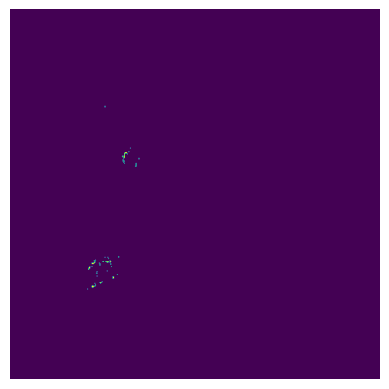

In [24]:
plt.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            ))
plt.axis("off")

In [8]:
model_num = get_best_epoch(43, "full",weight)

In [9]:
model_num

38

In [51]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "cxr14"
tgt_name = "n0352"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

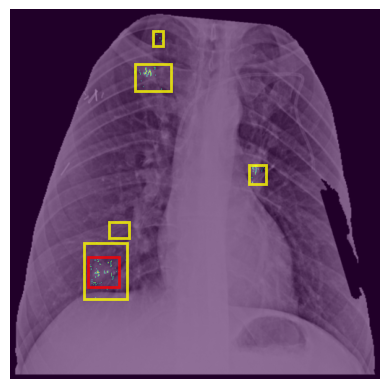

In [52]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [53]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.37493415784131945
Best Cov: 0.9542972369066434
Noise: 4
Attr Recall: 1


In [54]:
weight = "grey"
seed = 43
model_num = get_best_epoch(43, "first",weight)
data_name = "cxr14"
tgt_name = "n0352"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

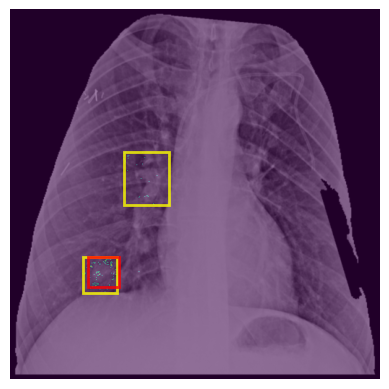

In [55]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [56]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.617745687441468
Best Cov: 0.8915145239522595
Noise: 1
Attr Recall: 1


In [72]:
weight = "single"
seed = 44
model_num = get_best_epoch(seed, "full",weight)
data_name = "cxr14"
tgt_name = "n0352"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

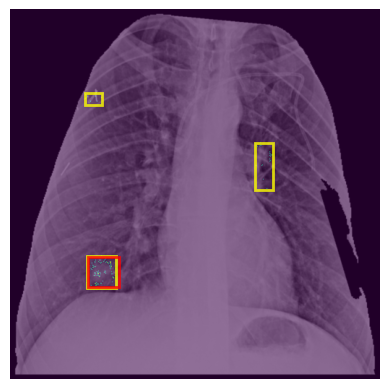

In [73]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [75]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.7628300136738744
Best Cov: 0.869540574418225
Noise: 2
Attr Recall: 1


### n0855

In [17]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "padchest"
tgt_name = "n0855"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

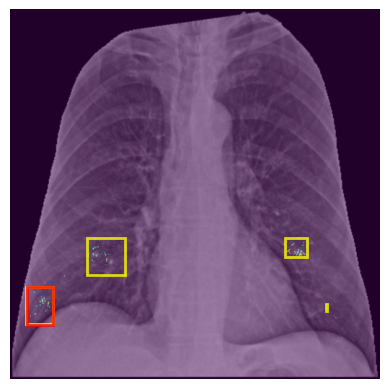

In [18]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [35]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.8541589374489876
Best Cov: 0.9337591888466417
Noise: 3
Attr Recall: 1


In [48]:
weight = "base"
seed = 42
model_num = get_best_epoch(43, "full",weight)
data_name = "padchest"
tgt_name = "n0855"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

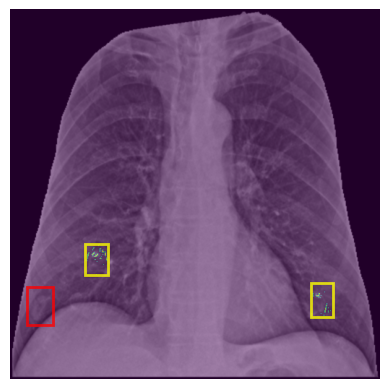

In [49]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [50]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.0
Best Cov: None
Noise: 2
Attr Recall: 0


In [39]:
weight = "grey"
seed = 43
model_num = get_best_epoch(43, "first",weight)
data_name = "padchest"
tgt_name = "n0855"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

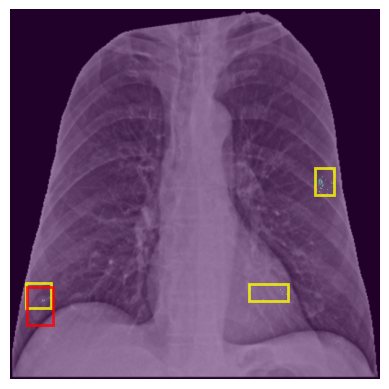

In [40]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [44]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        print(box)
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

(22, 379, 56, 413)
Best IoU: 0.4221811857934276
Best Cov: 0.47752598225602044
Noise: 2
Attr Recall: 1


### n0433

In [193]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "openi"
tgt_name = "n0433"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

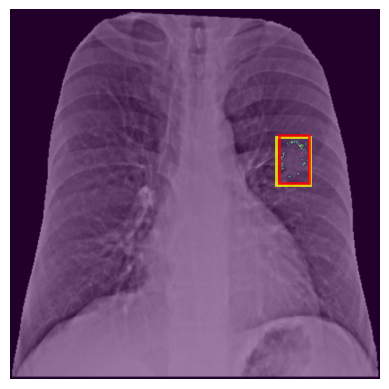

In [194]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [195]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "openi"
tgt_name = "n0433"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

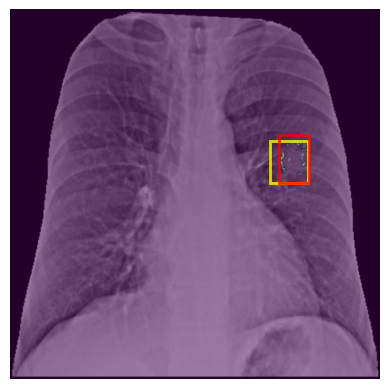

In [196]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [197]:
weight = "grey"
seed = 43
model_num = get_best_epoch(seed, "first",weight)
data_name = "openi"
tgt_name = "n0433"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

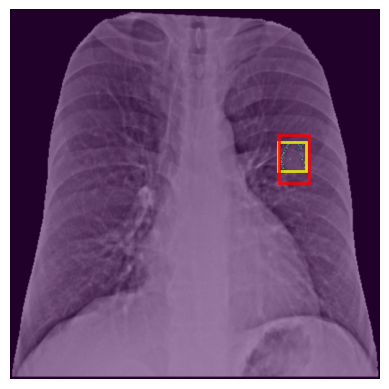

In [198]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

### n0293

In [199]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "jsrt"
tgt_name = "n0293"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

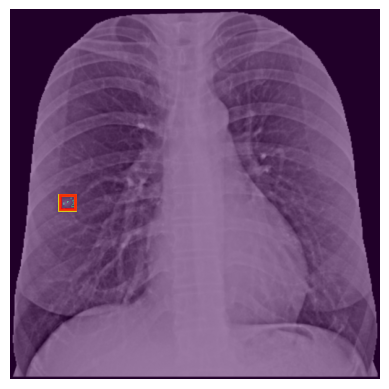

In [200]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [201]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "jsrt"
tgt_name = "n0293"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

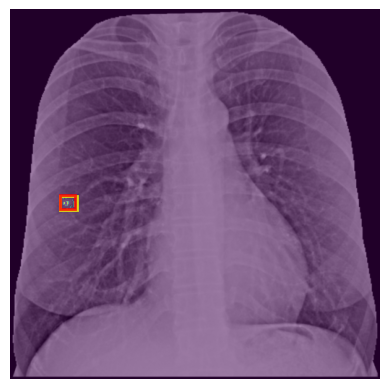

In [202]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [203]:
weight = "grey"
seed = 43
model_num = get_best_epoch(seed, "first",weight)
data_name = "jsrt"
tgt_name = "n0293"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

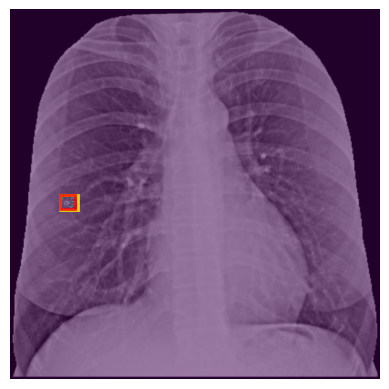

In [204]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

### n0885

In [205]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "jsrt"
tgt_name = "n0885"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

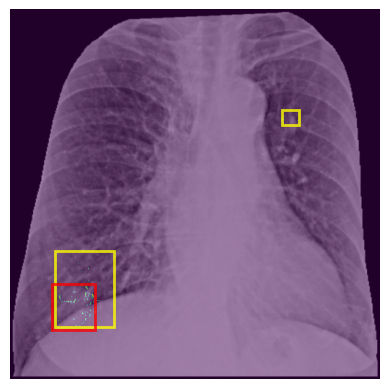

In [206]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [207]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "jsrt"
tgt_name = "n0885"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

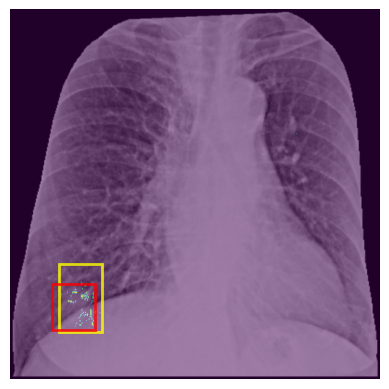

In [208]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [209]:
weight = "grey"
seed = 43
model_num = get_best_epoch(seed, "first",weight)
data_name = "jsrt"
tgt_name = "n0885"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

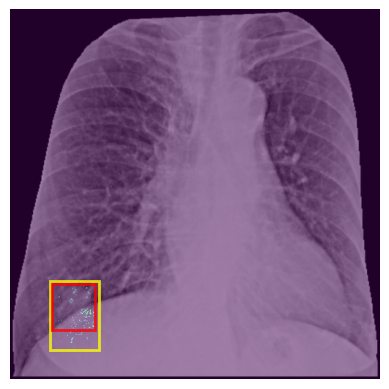

In [210]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

### n0931

In [211]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "jsrt"
tgt_name = "n0931"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

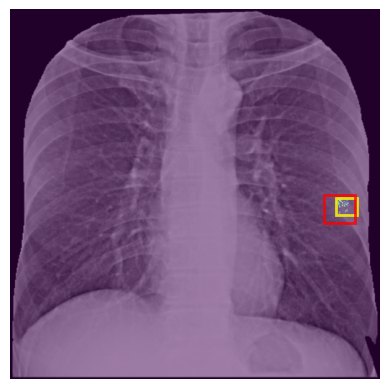

In [212]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [213]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "jsrt"
tgt_name = "n0931"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

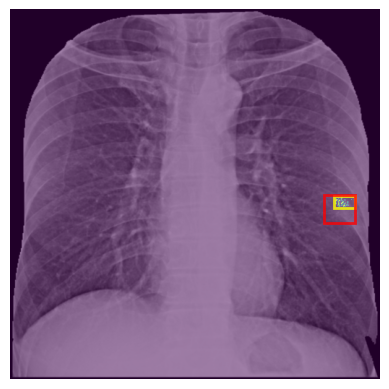

In [214]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [215]:
weight = "grey"
seed = 43
model_num = get_best_epoch(seed, "first",weight)
data_name = "jsrt"
tgt_name = "n0931"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

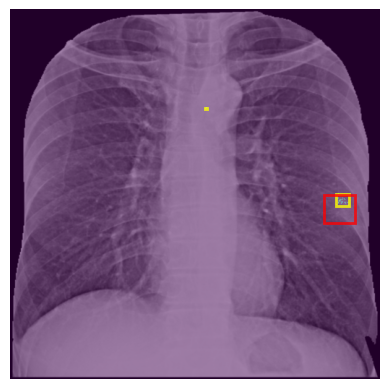

In [216]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

### n0407

In [76]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "padchest"
tgt_name = "n0407"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

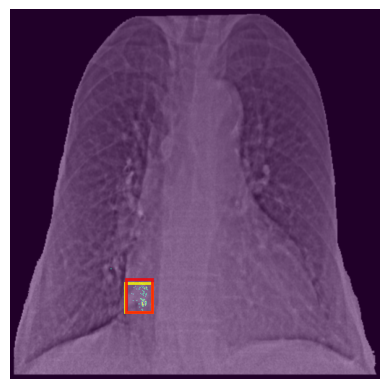

In [77]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [78]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.7687698157610888
Best Cov: 0.8204555760979526
Noise: 0
Attr Recall: 1


In [85]:
weight = "base"
seed = 42
model_num = get_best_epoch(seed, "full",weight)
data_name = "padchest"
tgt_name = "n0407"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

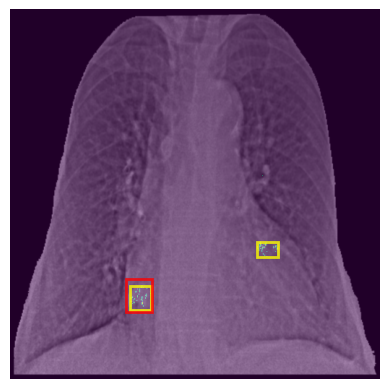

In [86]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [87]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.5420195878254823
Best Cov: 0.5617841653004036
Noise: 1
Attr Recall: 1


In [82]:
weight = "grey"
seed = 43
model_num = get_best_epoch(43, "first",weight)
data_name = "padchest"
tgt_name = "n0407"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

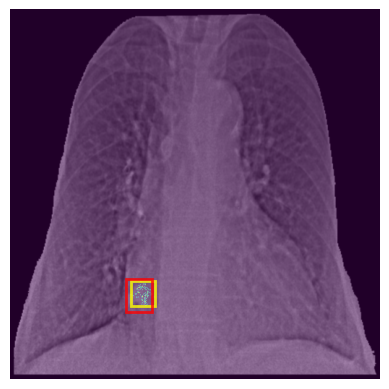

In [83]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [84]:
pos_curr_bbox2 = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
# track metrics
best_iou = 0.0
curr_noise = 0
best_cov = None
curr_intersect = 0
for i in range(0,len(tmp_boxes)):
    box = attr_boxes[i]#[attr_boxes.iloc[i].xmin, attr_boxes.iloc[i].ymin, attr_boxes.iloc[i].xmax, attr_boxes.iloc[i].ymax] 
    curr_iou = helpers.intersection.calculate_iou(pos_curr_bbox2, np.asarray(box))
    if not curr_iou > 0.0:
        curr_noise += 1
    if curr_iou > best_iou:
        best_iou = curr_iou
        best_cov = helpers.intersection.calculate_intersect_coverage(pos_curr_bbox2, np.asarray(box))
        curr_intersect = 1  

print(f"Best IoU: {best_iou}")
print(f"Best Cov: {best_cov}")
print(f"Noise: {curr_noise}")
print(f"Attr Recall: {curr_intersect}")

Best IoU: 0.5323738741575862
Best Cov: 0.5897024453204032
Noise: 0
Attr Recall: 1


### n1063

In [181]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "padchest"
tgt_name = "n1063"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

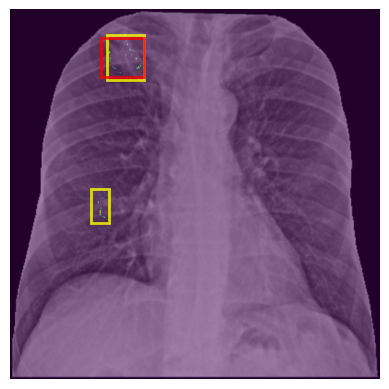

In [182]:
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [183]:
weight = "base"
seed = 42
model_num = get_best_epoch(43, "full",weight)
data_name = "padchest"
tgt_name = "n1063"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

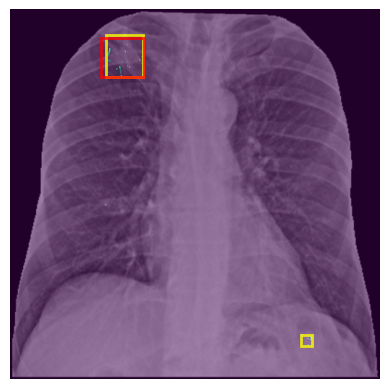

In [184]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

In [185]:
weight = "grey"
seed = 43
model_num = get_best_epoch(43, "first",weight)
data_name = "padchest"
tgt_name = "n1063"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

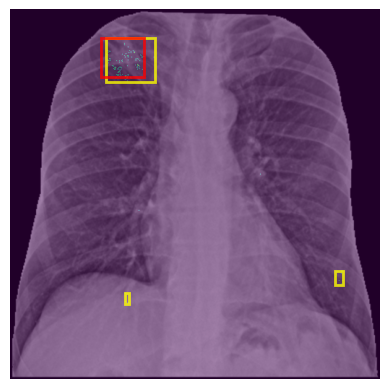

In [186]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

### N0973

In [217]:
weight = "single"
seed = "43"
model_num = "38"
data_name = "cxr14"
tgt_name = "n0973"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

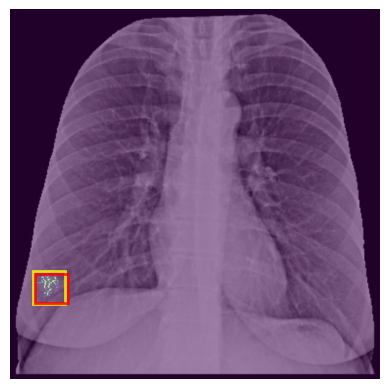

In [218]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

(-0.5, 511.5, 511.5, -0.5)

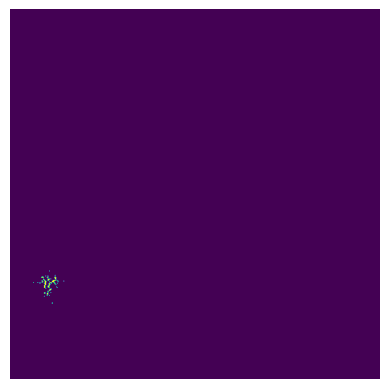

In [219]:
plt.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            ))
plt.axis("off")

In [220]:
weight = "base"
seed = 43
model_num = get_best_epoch(43, "full",weight)
data_name = "cxr14"
tgt_name = "n0973"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/full_network/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

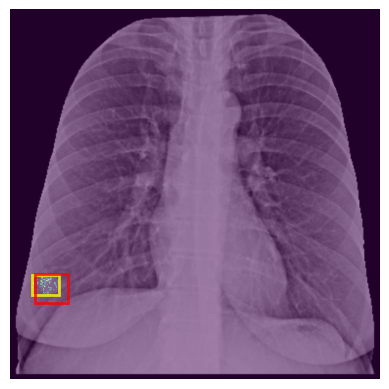

In [221]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

(-0.5, 511.5, 511.5, -0.5)

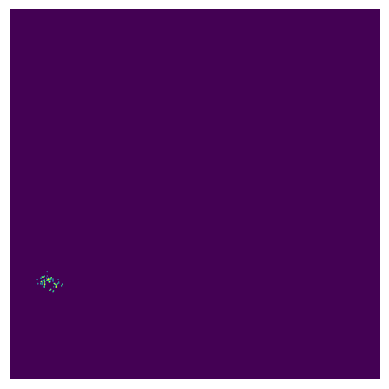

In [81]:
plt.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            ))
plt.axis("off")

In [82]:
weight = "grey"
seed = 43
model_num = get_best_epoch(43, "first",weight)
data_name = "cxr14"
tgt_name = "n0973"
model_pth = f"/home/local/data/sophie/padcxr14_models/step_decay_cxr14/arch_seg/first_layer_freeze/{weight}/lr_step_decay_10_epochs_0.1_rate/model_lr_0.0005_bsz_16_mom_0.99_seed_{seed}_pos-weight_1.0.pth/model_{model_num}.pth"
curr_model = helpers.models.load_trained_resnet50(model_pth,device="cpu", single = True if "single" in model_pth else False)
# load to GPU
curr_model=curr_model.to(device)
# create gradient model
curr_int_model = helpers.explainability.make_int_grad_model(curr_model)
ious = []
coverages = []
noises = []
intersects = []
img_names = []
testset_names =[]
# iterate over test sets
# for data_name in ['cxr14','padchest', 'openi' , 'jsrt']:
    # load data -> bsz = 1

dataset = helpers.dataloading.load_dataset_with_paths(
    dataset_path=f"/home/local/data/sophie/old_node21_versions/node21_num_label/{data_name}/arch_seg/flat_std_1024/test",
    dataset_name=data_name,
    process="arch",
    crop_size=512,
    batch_size=1,
    shuffle=False,
    single_channel = True if "single" in weight else False
)
# iterate over data samples
for data in dataset:
    # check for nodule
    # if data[1] == 1:
    if tgt_name in data[2][0]:
        # load to device
        pos_input, pos_path = data[0].to(device),data[2][0]
        img_names.append(pos_path.split("/")[-1][:-4])
        testset_names.append(data_name)
        # generate attr
        int_attr = helpers.explainability.get_occ_int_grad_for_single_tensor(
            curr_int_model, pos_input[0], 1, 
            single= True if "single" in weight else False, 
            window=8).squeeze(0)[0].cpu().numpy()
        # calculate attr bboxes
        attr_boxes = helpers.attribution.df_cc_bboxes_by_dbscan(
            helpers.attribution.get_area_thresheld_connected_components(
                helpers.attribution.threshold_attributions(
                    int_attr, 
                    min_thresh_frac=0.25, 
                    binary_mask=True
                    )), 30)
        # get current true bbox
        pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
        # convert from [x,y,w,h] to [x1,y1,x2,y2]
        pos_curr_bbox = [pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]
        break

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

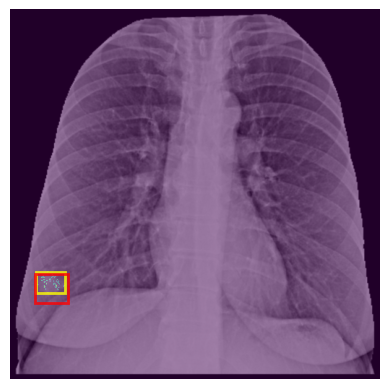

In [83]:
def draw_bboxes(bboxes, img):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 255, 0), 3)
    return img
thresh_frac = 0.25
nebr = 30

tmp_boxes = attr_boxes
fig, ax = plt.subplots(1,1)
pos_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[pos_path.split("/")[-1][:-4]]],224,512)[0]
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor='red', facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
tmp_img = helpers.attribution.convert_to_uint8(cv2.cvtColor(pos_input[0][0].cpu().unsqueeze(2).numpy(), cv2.COLOR_RGB2BGR))
# tmp_img = draw_bboxes(tmp_boxes, img=tmp_img)
ax.imshow(tmp_img)
# ax.imshow(plt.imread(pos_path[0]))
ax.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            ),alpha=0.5)

for bbox in tmp_boxes:
    x_min, y_min, x_max, y_max = np.array(bbox).astype(int)
    rect2 = patches.Rectangle((x_min,y_min),x_max-x_min,y_max-y_min,edgecolor='yellow', facecolor='none',
                              lw=2, alpha=0.8,ls="-")
    ax.add_patch(rect2)
ax.add_patch(rect)
ax.axis("off")

(-0.5, 511.5, 511.5, -0.5)

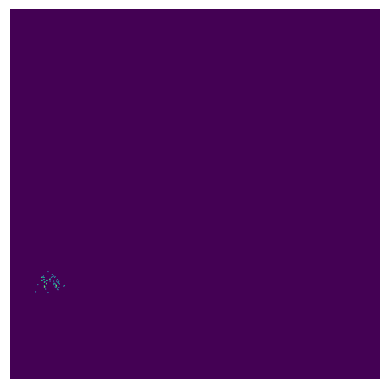

In [84]:
plt.imshow(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            ))
plt.axis("off")

(-0.5, 511.5, 511.5, -0.5)

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "dpi" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument

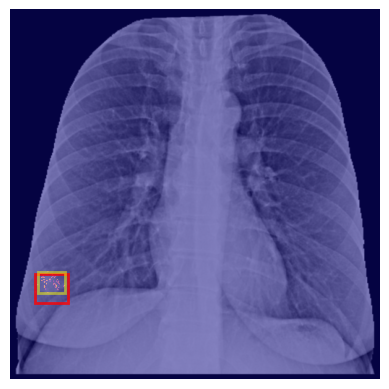

In [164]:
import matplotlib.patches as patches
curr_attr = helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            )
fig, ax = plt.subplots()
ax.imshow(tmp_img)
ax.imshow(curr_attr,alpha=0.5, cmap="plasma")
# rect = patches.Rectangle((curr_bbox_reshaped[0],curr_bbox_reshaped[1]),curr_bbox_reshaped[2]-curr_bbox_reshaped[0],curr_bbox_reshaped[3]-curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
#                          facecolor='none',lw=2)
# ax.add_patch(rect)
rect = patches.Rectangle((pos_curr_bbox[0],pos_curr_bbox[1]),pos_curr_bbox[2],pos_curr_bbox[3],edgecolor=(1,0,0,0.5), facecolor='none',lw=2, 
                         alpha=0.8)#, ls=":")
ax.add_patch(rect)
cc_df = helpers.attribution.attribution_bbox_with_connected_components(curr_attr)
# for i in range(0,len(cc_df)):
#     rect = patches.Rectangle((cc_df.iloc[i].xmin,cc_df.iloc[i].ymin),
#                              cc_df.iloc[i].xmax-cc_df.iloc[i].xmin,
#                              cc_df.iloc[i].ymax-cc_df.iloc[i].ymin,
#                              edgecolor=(0,1,0,0.5),
#                          facecolor='none',lw=2)
#     ax.add_patch(rect)
curr_attr_bboxes = helpers.attribution.df_cc_bboxes_by_dbscan(helpers.attribution.attribution_bbox_with_connected_components(curr_attr))
i=0
for cc_box in curr_attr_bboxes:
    # if i!=0:
    # [(38, 363, 76, 393)]
    rect = patches.Rectangle((cc_box[0],cc_box[1]),
                             cc_box[2]-cc_box[0],
                             cc_box[3]-cc_box[1],
                             edgecolor=(1,1,0,0.5),
                         facecolor='none',lw=2)
    ax.add_patch(rect)
    # i+=1
ax.axis("off")

In [160]:
curr_attr_bboxes

[(38, 363, 76, 393)]

In [157]:
helpers.attribution.get_area_thresheld_connected_components(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=0.25, 
                binary_mask=True
            ))

,centroid,xmin,xmax,ymin,ymax
0,"[52.0, 363.0]",52,53,363,364
1,"[58.0, 367.0]",58,59,367,368
2,"[46.0, 369.0]",46,47,369,370
3,"[60.0, 369.0]",60,61,369,370
4,"[43.666666666666664, 370.6666666666667]",43,45,370,372
5,"[46.5, 371.0]",46,48,371,372
6,"[57.5, 370.5]",57,59,370,372
7,"[61.5, 370.5]",61,63,370,372
8,"[54.666666666666664, 373.6666666666667]",54,56,373,375
9,"[43.5, 375.0]",43,45,375,376


In [25]:
helpers.attribution.df_cc_bboxes_by_dbscan(helpers.attribution.get_area_thresheld_connected_components(helpers.attribution.threshold_attributions(
                int_attr, 
                min_thresh_frac=thresh_frac, 
                binary_mask=True
            )), nebr)

[(70, 218, 90, 265), (95, 338, 120, 361), (367, 371, 383, 377)]

In [28]:
[pos_curr_bbox[0],pos_curr_bbox[1],pos_curr_bbox[0]+pos_curr_bbox[2], pos_curr_bbox[1]+pos_curr_bbox[3]]

[96.0, 331.4285714285714, 123.42857142857143, 370.2857142857142]

## Debugging Plots

In [8]:
img = "n0996"

In [9]:
attr_type = "occ" #"int"
weight_type = "grey" #"grey" "single"
training_type = "full"
run_seed = 42 # 43 44
grey_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[img]], 224, 512)
grey_curr_bbox_reshaped = [grey_curr_bbox[0][0], grey_curr_bbox[0][1], grey_curr_bbox[0][0]+grey_curr_bbox[0][2], grey_curr_bbox[0][1]+grey_curr_bbox[0][3]]
grey_curr_pth = get_attr_pth(attr_type, training_type, weight_type, run_seed, img)
grey_curr_attr = helpers.attribution.load_attr(grey_curr_pth)
thresh_grey_curr_attr =  cv2.threshold(grey_curr_attr, 170, 255, cv2.THRESH_BINARY)[1]

In [19]:
attr_type = "occ" #"int"
weight_type = "base" #"grey" "single"
training_type = "full"
run_seed = 42 # 43 44
base_curr_bbox = helpers.bboxes.resize_bboxes([bbox_df[img]], 224, 512)
base_curr_bbox_reshaped = [base_curr_bbox[0][0], base_curr_bbox[0][1], base_curr_bbox[0][0]+base_curr_bbox[0][2], base_curr_bbox[0][1]+base_curr_bbox[0][3]]
base_curr_pth = get_attr_pth(attr_type, training_type, weight_type, run_seed, img)
base_curr_attr = helpers.attribution.load_attr(base_curr_pth)
thresh_base_curr_attr =  cv2.threshold(grey_curr_attr, 170, 255, cv2.THRESH_BINARY)[1]

(-0.5, 511.5, 511.5, -0.5)

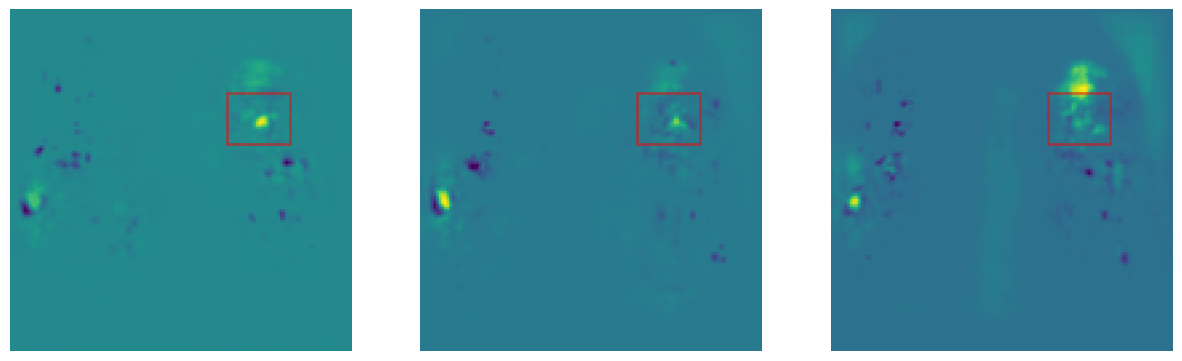

In [25]:
import matplotlib.patches as patches

fig, axs = plt.subplots(nrows=1, ncols=3,figsize=(15, 45))
axs[0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0996.png"))
axs[1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model1/n0996.png"))
axs[2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model1/n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[2].add_patch(rect)
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')

(-0.5, 511.5, 511.5, -0.5)

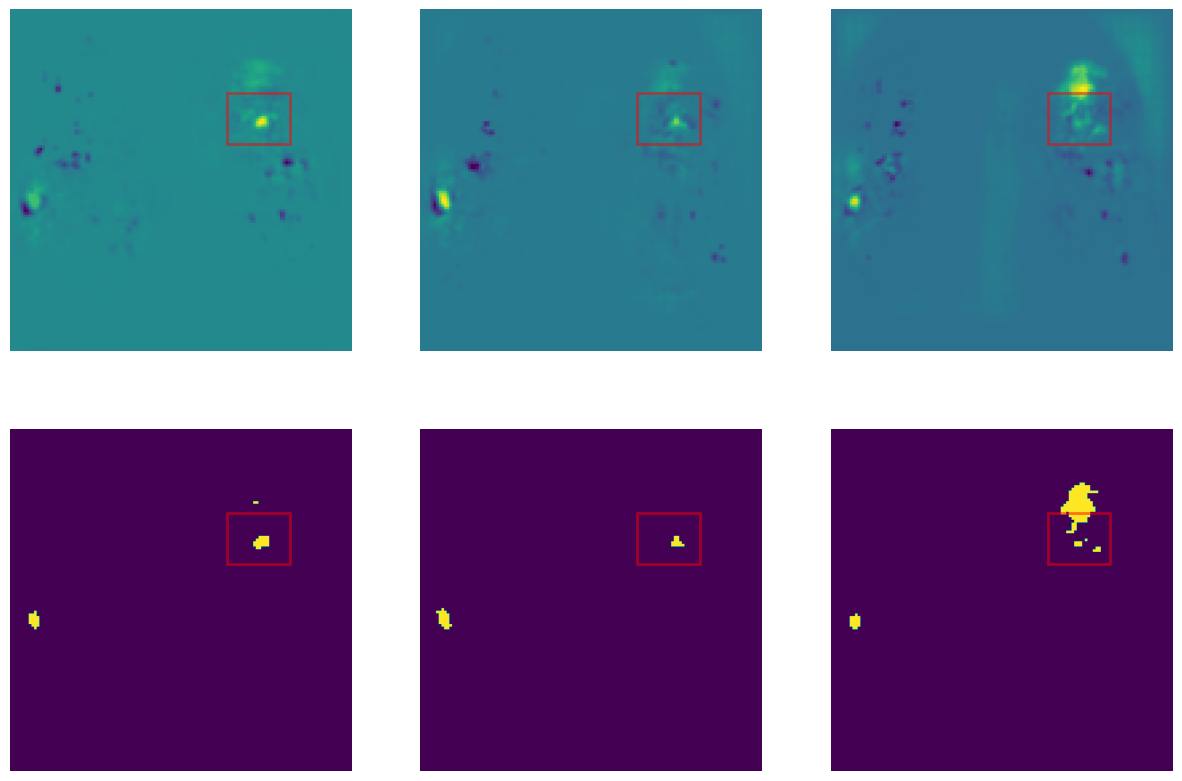

In [37]:
import matplotlib.patches as patches

fig, axs = plt.subplots(nrows=2, ncols=3,figsize=(15, 10))
axs[0][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/n0996.png"))
axs[0][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model1/n0996.png"))
axs[0][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model1/n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][1].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][2].add_patch(rect)
axs[0][0].axis('off')
axs[0][1].axis('off')
axs[0][2].axis('off')

axs[1][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model1/thresh_n0996.png"))
axs[1][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model1/thresh_n0996.png"))
axs[1][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model1/thresh_n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][1].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][2].add_patch(rect)
axs[1][0].axis('off')
axs[1][1].axis('off')
axs[1][2].axis('off')

(-0.5, 511.5, 511.5, -0.5)

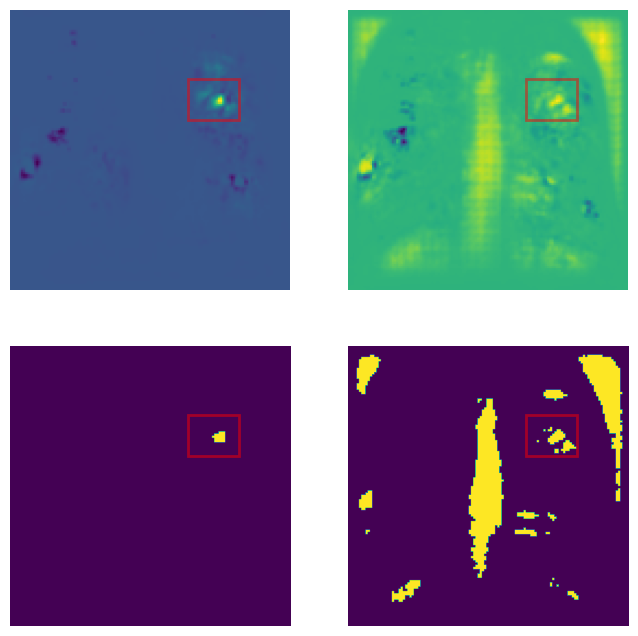

In [41]:
import matplotlib.patches as patches

fig, axs = plt.subplots(nrows=2, ncols=2,figsize=(8, 8))
axs[0][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model2/n0996.png"))
axs[0][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model2/n0996.png"))
# axs[0][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model2/n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][1].add_patch(rect)
# rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
#                          facecolor='none',lw=2)
# axs[0][2].add_patch(rect)
axs[0][0].axis('off')
axs[0][1].axis('off')
# axs[0][2].axis('off')

axs[1][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model2/thresh_n0996.png"))
axs[1][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model2/thresh_n0996.png"))
# axs[1][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model2/thresh_n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][1].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
# axs[1][2].add_patch(rect)
axs[1][0].axis('off')
axs[1][1].axis('off')
# axs[1][2].axis('off')

(-0.5, 511.5, 511.5, -0.5)

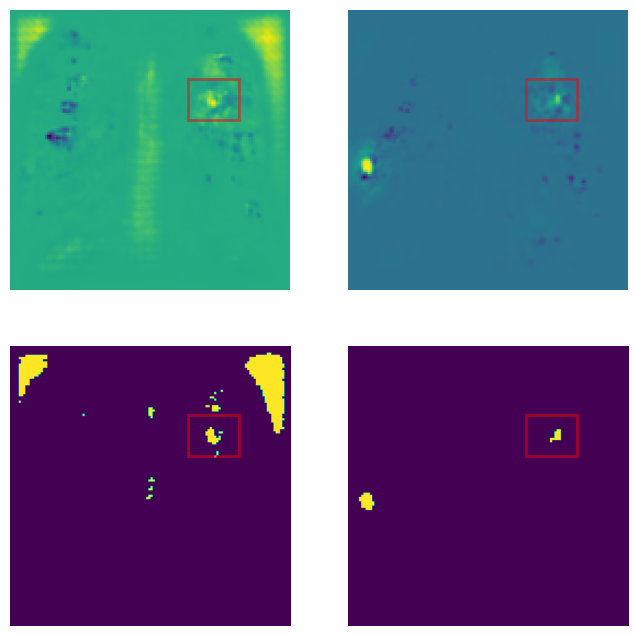

In [42]:
import matplotlib.patches as patches

fig, axs = plt.subplots(nrows=2, ncols=2,figsize=(8, 8))
axs[0][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model3/n0996.png"))
axs[0][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model3/n0996.png"))
# axs[0][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model2/n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[0][1].add_patch(rect)
# rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
#                          facecolor='none',lw=2)
# axs[0][2].add_patch(rect)
axs[0][0].axis('off')
axs[0][1].axis('off')
# axs[0][2].axis('off')

axs[1][0].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/base/model3/thresh_n0996.png"))
axs[1][1].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/grey/model3/thresh_n0996.png"))
# axs[1][2].imshow(plt.imread("/home/local/data/sophie/DGX_GridSearch/attributions/occlusion/full/single/model2/thresh_n0996.png"))
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][0].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
axs[1][1].add_patch(rect)
rect = patches.Rectangle((base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[1]),base_curr_bbox_reshaped[2]-base_curr_bbox_reshaped[0],base_curr_bbox_reshaped[3]-base_curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
# axs[1][2].add_patch(rect)
axs[1][0].axis('off')
axs[1][1].axis('off')
# axs[1][2].axis('off')

(-0.5, 511.5, 511.5, -0.5)

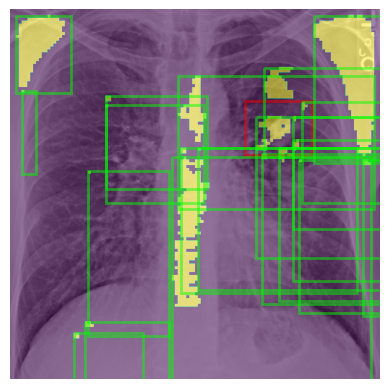

In [89]:
import matplotlib.patches as patches
fig, ax = plt.subplots()
ax.imshow(cv2.resize(cv2.imread(f"/home/local/data/sophie/cxr14/crop/std_1024/test/nodule/{img}.png"), 
           (512,512), interpolation= cv2.INTER_LINEAR))
ax.imshow(curr_attr, alpha=0.5)
rect = patches.Rectangle((curr_bbox_reshaped[0],curr_bbox_reshaped[1]),curr_bbox_reshaped[2]-curr_bbox_reshaped[0],curr_bbox_reshaped[3]-curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
ax.add_patch(rect)
for cc_box in curr_attr_bboxes:
    rect = patches.Rectangle((cc_box[0],cc_box[1]),
                             cc_box[2],
                             cc_box[3],
                             edgecolor=(0,1,0,0.5),
                         facecolor='none',lw=2)
    ax.add_patch(rect)
ax.axis("off")

(-0.5, 511.5, 511.5, -0.5)

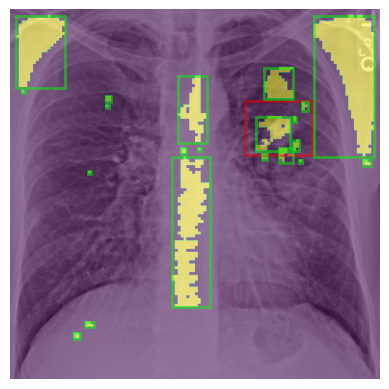

In [88]:
import matplotlib.patches as patches
fig, ax = plt.subplots()
ax.imshow(cv2.resize(cv2.imread(f"/home/local/data/sophie/cxr14/crop/std_1024/test/nodule/{img}.png"), 
           (512,512), interpolation= cv2.INTER_LINEAR))
ax.imshow(curr_attr, alpha=0.5)
rect = patches.Rectangle((curr_bbox_reshaped[0],curr_bbox_reshaped[1]),curr_bbox_reshaped[2]-curr_bbox_reshaped[0],curr_bbox_reshaped[3]-curr_bbox_reshaped[1],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
ax.add_patch(rect)

cc_df = helpers.attribution.attribution_bbox_with_connected_components(curr_attr)
for i in range(0,len(cc_df)):
    rect = patches.Rectangle((cc_df.iloc[i].xmin,cc_df.iloc[i].ymin),
                             cc_df.iloc[i].xmax-cc_df.iloc[i].xmin,
                             cc_df.iloc[i].ymax-cc_df.iloc[i].ymin,
                             edgecolor=(0,1,0,0.5),
                         facecolor='none',lw=2)
    ax.add_patch(rect)
# for cc_box in curr_attr_bboxes:
#     rect = patches.Rectangle((cc_box[0],cc_box[1]),
#                              cc_box[2],
#                              cc_box[3],
#                              edgecolor=(0,1,0,0.5),
#                          facecolor='none',lw=1)
#     ax.add_patch(rect)
ax.axis("off")

In [5]:
plot_box = curr_bbox[0]

(-0.5, 511.5, 511.5, -0.5)

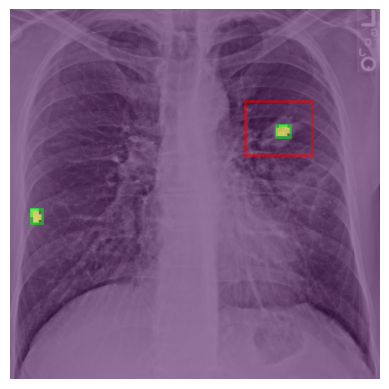

In [6]:
import matplotlib.patches as patches
fig, ax = plt.subplots()
ax.imshow(cv2.resize(cv2.imread(f"/home/local/data/sophie/cxr14/crop/std_1024/test/nodule/{img[:-4]}.png"), 
           (512,512), interpolation= cv2.INTER_LINEAR))
ax.imshow(curr_attr, alpha=0.5)
rect = patches.Rectangle((plot_box[0],plot_box[1]),plot_box[2],plot_box[3],edgecolor=(1,0,0,0.5),
                         facecolor='none',lw=2)
ax.add_patch(rect)
for cc_box in curr_attr_bboxes:
    rect = patches.Rectangle((cc_box[0],cc_box[1]),
                             cc_box[2]-cc_box[0],
                             cc_box[3]-cc_box[1],
                             edgecolor=(0,1,0,0.5),
                         facecolor='none',lw=2)
    ax.add_patch(rect)
ax.axis("off")